In [203]:
# ================================================================
# 🥇 Gold Bot v2 — Moteur de Backtest Ultra-Fidèle (Tick-by-Tick)
# ================================================================
# Architecture : M5 (signaux) → Ticks (exécution chirurgicale)
# Données      : 1 an | ~141.7M ticks | Polars LazyFrame
# Vs           : M1 (approximatif) pour mesurer l'impact de précision
# ================================================================

In [204]:
# ============================================================
# REMPLACEMENT CELLULE 1 — Configuration globale
# BUG : PNL_PER_POINT et SLIPPAGE_PTS étaient redéfinis dans
# la Cellule 5b (PNL_PER_POINT=9.0, SLIPPAGE_PTS=0.05),
# écrasant silencieusement les valeurs globales.
# CORRECTION : Ces constantes ne doivent être déclarées QU'ICI.
# La Cellule 5b ne doit plus les redéclarer.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import time
from datetime import timedelta
from pathlib import Path
from collections import OrderedDict
import tqdm.notebook as tqdmn
from tqdm.notebook import tqdm
 
try:
    import polars as pl
    print(f'✅ Polars {pl.__version__} disponible')
except ImportError:
    raise ImportError("Installez polars : pip install polars")
 
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
 
PATH_M1     = Path('data/XAUUSD-VIP_M1_1Year.csv')
PATH_M5     = Path('data/XAUUSD-VIP_M5_1Year.csv')
PATH_TICKS  = Path('data/XAUUSD-VIP_Ticks_1Year.csv')
 
LOT_SIZE         = 0.03
PNL_PER_POINT    = 3.0        # 0.03 lot × 100 $/point (XAU) — NE PAS REDÉFINIR AILLEURS
MAX_RISK_PTS     = 22.0
DAILY_MAX_LOSS   = -150.0
SESSION_MID_H    = 12         # GMT+2
SESSION_END_H    = 15         # GMT+2
GMT_OFFSET       = -1         # Broker GMT+3 → PC GMT+2
MAX_TRADES_PER_DAY = 60
 
# ── Friction réelle — valeur unique, source de vérité ────────
SLIPPAGE_PTS = 0.1            # NE PAS REDÉFINIR DANS LES CELLULES SUIVANTES
 
MODES_CONFIG = {
    'safe':      {'sl_mult': 2.5, 'tp1_mult': 1.5, 'tp2_mult': 2.5, 'tp3_mult': 4.0, 'score_min': 60, 'cooldown': 300},
    'risque':    {'sl_mult': 1.8, 'tp1_mult': 1.2, 'tp2_mult': 2.0, 'tp3_mult': 3.2, 'score_min': 45, 'cooldown': 180},
    'risque+++': {'sl_mult': 1.5, 'tp1_mult': 1.0, 'tp2_mult': 1.8, 'tp3_mult': 2.8, 'score_min': 45, 'cooldown': 90},
    'optimale':  {'sl_mult': 1.2, 'tp1_mult': 1.0, 'tp2_mult': 1.8, 'tp3_mult': 2.8, 'score_min': 35, 'cooldown': 90},
}
TRADING_MODE = 'risque+++'
print('✅ Imports et configuration OK')
print(f'   Mode : {TRADING_MODE} | Score min : {MODES_CONFIG[TRADING_MODE]["score_min"]} | SL mult : {MODES_CONFIG[TRADING_MODE]["sl_mult"]}')
print(f'   PNL_PER_POINT = {PNL_PER_POINT} | SLIPPAGE_PTS = {SLIPPAGE_PTS}')

✅ Polars 1.40.1 disponible
✅ Imports et configuration OK
   Mode : risque+++ | Score min : 45 | SL mult : 1.5
   PNL_PER_POINT = 3.0 | SLIPPAGE_PTS = 0.1


In [205]:
# ============================================================
# CELLULE 2 — Chargement M5 & M1 (pandas) + peek ticks (Polars)
# ============================================================
def load_csv(path: Path, label: str) -> pd.DataFrame:
    """Charge un CSV OHLCV broker avec correction GMT+3 → GMT+2."""
    df = pd.read_csv(path, parse_dates=['Time'])
    df.rename(columns={'TickVolume': 'Volume'}, inplace=True)
    df['Time'] = df['Time'] + pd.Timedelta(hours=GMT_OFFSET)
    df.set_index('Time', inplace=True)
    df.sort_index(inplace=True)
    df[['Open', 'High', 'Low', 'Close', 'Volume']] = \
        df[['Open', 'High', 'Low', 'Close', 'Volume']].astype(float)
    print(f'✅ {label} chargé : {len(df):,} bougies | {df.index[0]} → {df.index[-1]}')
    return df

df_m5 = load_csv(PATH_M5, 'M5')
df_m1 = load_csv(PATH_M1, 'M1')

# ── Détection du format des ticks (les premières lignes) ─────
print('\n🔍 Détection du format tick CSV...')
with open(PATH_TICKS, 'r') as f:
    for i, line in enumerate(f):
        print(f'  Ligne {i}: {line.strip()}')
        if i >= 3:
            break

# ── Calcul de la taille du fichier ───────────────────────────
tick_size_gb = PATH_TICKS.stat().st_size / 1e9
print(f'\n📊 Fichier ticks : {tick_size_gb:.2f} GB')
print('   → Polars LazyFrame : pas de chargement complet en RAM')
print('   → Filtrage par plage de temps par trade uniquement')


✅ M5 chargé : 70,860 bougies | 2025-05-09 00:00:00 → 2026-05-08 22:55:00
✅ M1 chargé : 353,688 bougies | 2025-05-09 00:00:00 → 2026-05-08 22:56:00

🔍 Détection du format tick CSV...
  Ligne 0: Time,Bid,Ask,Last,Volume
  Ligne 1: 2025.05.09 01:00:08.257,3307.88,3308.20,0.00,0
  Ligne 2: 2025.05.09 01:00:10.332,3307.93,3308.25,0.00,0
  Ligne 3: 2025.05.09 01:00:12.084,3307.92,3308.24,0.00,0

📊 Fichier ticks : 6.80 GB
   → Polars LazyFrame : pas de chargement complet en RAM
   → Filtrage par plage de temps par trade uniquement


In [206]:
# ============================================================
# CELLULE 2b (NOUVEAU) — Conversion CSV → Parquet (UNE SEULE FOIS)
# ============================================================
# À exécuter UNE SEULE FOIS. Crée data/ticks.parquet (~1.2 GB).
# Ensuite commenter le bloc convert_to_parquet() et ne garder
# que PATH_TICKS_PARQUET.
import os, time
import polars as pl
from pathlib import Path

PATH_TICKS        = Path('data/XAUUSD-VIP_Ticks_1Year.csv')
PATH_TICKS_PARQUET= Path('data/XAUUSD-VIP_Ticks_1Year.parquet')

def convert_ticks_to_parquet():
    """
    Convertit le CSV de ticks en Parquet.
    UNE SEULE FOIS — ensuite le Parquet est réutilisé directement.

    Stratégie :
    - Lire par chunks de 5M lignes pour ne pas exploser la RAM
    - Ne garder que les colonnes Bid et Ask + temps normalisé
    - Stocker en Parquet partitionné par date (lecture sélective ensuite)
    """
    if PATH_TICKS_PARQUET.exists():
        size_gb = PATH_TICKS_PARQUET.stat().st_size / 1e9
        print(f'✅ Parquet déjà existant ({size_gb:.2f} GB) — conversion ignorée')
        return
   
    

    print(f'⏳ Conversion CSV → Parquet ({PATH_TICKS.stat().st_size/1e9:.1f} GB)...')
    print('   Cela prend 5-15 min selon votre disque (SSD ~5 min, HDD ~15 min)')
    print('   À faire UNE SEULE FOIS !\n')
    t0 = time.time()

    # Lire le header pour détecter les colonnes
    with open(PATH_TICKS, 'r') as f:
        header_line = f.readline().strip()
    raw_cols = [c.strip().strip('<>') for c in header_line.split(',')]

    # Trouver les colonnes Bid, Ask, Time
    time_col = next((c for c in raw_cols if 'time' in c.lower() or c.lower() == 'date'), raw_cols[0])
    bid_col  = next((c for c in raw_cols if 'bid'  in c.lower()), None)
    ask_col  = next((c for c in raw_cols if 'ask'  in c.lower()), None)

    if bid_col is None or ask_col is None:
        raise ValueError(f'Colonnes Bid/Ask non trouvées dans : {raw_cols}')

    print(f'   Colonnes détectées : Time="{time_col}" Bid="{bid_col}" Ask="{ask_col}"')

    # Lecture en streaming Polars + écriture Parquet
    # scan_csv + sink_parquet = jamais tout en RAM
    (
        pl.scan_csv(
            PATH_TICKS,
            try_parse_dates=False,
            infer_schema_length=500,
        )
        .select([time_col, bid_col, ask_col])
        .rename({time_col: 'RawTime', bid_col: 'Bid', ask_col: 'Ask'})
        .with_columns([
            pl.col('Bid').cast(pl.Float64),
            pl.col('Ask').cast(pl.Float64),
            pl.col('RawTime')
                .str.to_datetime(format='%Y.%m.%d %H:%M:%S%.3f', strict=False)
                .alias('Time')
])
        .drop('RawTime')
        .sink_parquet(PATH_TICKS_PARQUET, compression='snappy')
    )

    elapsed = time.time() - t0
    size_gb = PATH_TICKS_PARQUET.stat().st_size / 1e9
    print(f'\n✅ Parquet créé : {size_gb:.2f} GB en {elapsed:.0f}s')
    print(f'   (Taille réduite de {PATH_TICKS.stat().st_size/1e9:.1f} → {size_gb:.1f} GB)')
    print(f'   Lectures futures : ~50x plus rapides')

# ── Lancer la conversion si nécessaire ───────────────────────
convert_ticks_to_parquet()

# ── LazyFrame Parquet (prêt pour les requêtes) ────────────────
_TICKS_PARQUET_LAZY = pl.scan_parquet(PATH_TICKS_PARQUET)
print('\n✅ LazyFrame Parquet prêt')

✅ Parquet déjà existant (1.46 GB) — conversion ignorée

✅ LazyFrame Parquet prêt


In [207]:
# ============================================================
# CELLULE 3 — Fonctions Indicateurs (répliques exactes du bot)
# ============================================================
def compute_vwap(df: pd.DataFrame, window: int = 50) -> pd.Series:
    typical = (df['High'] + df['Low'] + df['Close']) / 3
    tp_vol  = typical * df['Volume']
    return tp_vol.rolling(window).sum() / df['Volume'].rolling(window).sum()

def compute_volume_profile(df: pd.DataFrame, bins: int = 20) -> dict:
    price_min = df['Low'].min()
    price_max = df['High'].max()
    if price_max == price_min:
        return {'poc': df['Close'].iloc[-1], 'value_area_high': price_max, 'value_area_low': price_min}
    volumes, edges = np.histogram(df['Close'], bins=bins, weights=df['Volume'])
    poc_idx = volumes.argmax()
    poc     = (edges[poc_idx] + edges[poc_idx + 1]) / 2
    target  = volumes.sum() * 0.70
    sorted_i = np.argsort(volumes)[::-1]
    acc, va_i = 0, []
    for idx in sorted_i:
        acc += volumes[idx]; va_i.append(idx)
        if acc >= target: break
    va_high = max((edges[i] + edges[i + 1]) / 2 for i in va_i)
    va_low  = min((edges[i] + edges[i + 1]) / 2 for i in va_i)
    return {'poc': round(poc, 2), 'value_area_high': round(va_high, 2), 'value_area_low': round(va_low, 2)}

def compute_atr(df: pd.DataFrame, window: int = 14) -> float:
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift()).abs(),
        (df['Low']  - df['Close'].shift()).abs(),
    ], axis=1).max(axis=1)
    return round(tr.rolling(window).mean().iloc[-1], 2)

def _detect_candle_pattern(df: pd.DataFrame) -> str:
    o, h, l, c = df['Open'].iloc[-1], df['High'].iloc[-1], df['Low'].iloc[-1], df['Close'].iloc[-1]
    body   = abs(c - o); candle = h - l
    if candle == 0: return 'Doji'
    ratio       = body / candle
    lower_wick  = min(o, c) - l
    upper_wick  = h - max(o, c)
    if ratio < 0.1:                                                    return 'Doji'
    if lower_wick > body * 2 and upper_wick < body * 0.5 and c > o:   return 'Marteau'
    if upper_wick > body * 2 and lower_wick < body * 0.5 and c < o:   return 'Shooting Star'
    prev_o, prev_c = df['Open'].iloc[-2], df['Close'].iloc[-2]
    if c > o and c > prev_o and o < prev_c and prev_c < prev_o:        return 'Engulfing haussier'
    if c < o and c < prev_o and o > prev_c and prev_c > prev_o:        return 'Engulfing baissier'
    if lower_wick > body * 3:                                          return 'Pin Bar haussier'
    if upper_wick > body * 3:                                          return 'Pin Bar baissier'
    return 'Neutre'

def compute_indicators(df: pd.DataFrame) -> dict:
    close = df['Close']; high = df['High']; low = df['Low']; vol = df['Volume']
    price = close.iloc[-1]
    atr   = compute_atr(df)
    vwap_series = compute_vwap(df, window=50)
    vwap  = vwap_series.iloc[-1]
    typical     = (high + low + close) / 3
    vwap_std    = (typical - vwap_series).rolling(50).std().iloc[-1]
    if np.isnan(vwap_std) or vwap_std == 0: vwap_std = 1e-9
    vwap_upper1 = round(vwap + 1.0 * vwap_std, 2)
    vwap_lower1 = round(vwap - 1.0 * vwap_std, 2)
    vwap_upper2 = round(vwap + 2.0 * vwap_std, 2)
    vwap_lower2 = round(vwap - 2.0 * vwap_std, 2)
    dist_vwap   = round(price - vwap, 2)
    dist_vwap_sd= round(dist_vwap / vwap_std, 2)
    vwap_slope  = round(vwap_series.diff(5).iloc[-1], 2)
    vp  = compute_volume_profile(df.tail(100))
    poc = vp['poc']
    near_poc              = abs(price - poc) < atr * 0.5
    swing_high            = round(df.tail(30)['High'].max(), 2)
    swing_low             = round(df.tail(30)['Low'].min(), 2)
    near_swing_support    = abs(price - swing_low)  < atr * 1.0
    near_swing_resistance = abs(price - swing_high) < atr * 1.0
    ema200      = close.ewm(span=200, adjust=False).mean().iloc[-1]
    above_200   = price > ema200
    ema20       = close.ewm(span=20, adjust=False).mean()
    ema50       = close.ewm(span=50, adjust=False).mean()
    ema_cross_bull = (ema20.iloc[-1] > ema50.iloc[-1] and ema20.iloc[-2] <= ema50.iloc[-2])
    ema_cross_bear = (ema20.iloc[-1] < ema50.iloc[-1] and ema20.iloc[-2] >= ema50.iloc[-2])
    avg_vol     = vol.rolling(20).mean().iloc[-1]
    vol_ratio   = round(vol.iloc[-1] / avg_vol, 2) if avg_vol > 0 else 1.0
    vol_spike   = vol_ratio > 1.4
    cur_open    = df['Open'].iloc[-1]; cur_close = close.iloc[-1]
    cur_body    = abs(cur_close - cur_open)
    cur_bull    = cur_close > cur_open; cur_bear = cur_close < cur_open
    last10      = close.iloc[-11:-1]
    move10      = last10.iloc[-1] - last10.iloc[0]
    above_50    = price > ema50.iloc[-1]
    bounce_bull = (near_swing_support and cur_bull and cur_body > atr * 0.5
                   and vol_ratio > 1.4 and move10 < -atr * 1.5
                   and (not above_200 or (above_200 and near_poc)))
    bounce_bear = (near_swing_resistance and cur_bear and cur_body > atr * 0.5
                   and vol_ratio > 1.4 and move10 > atr * 1.5)
    pattern     = _detect_candle_pattern(df)
    return {
        'price': round(price, 2), 'atr': atr,
        'vwap': round(vwap, 2), 'vwap_upper1': vwap_upper1, 'vwap_lower1': vwap_lower1,
        'vwap_upper2': vwap_upper2, 'vwap_lower2': vwap_lower2,
        'dist_vwap_sd': dist_vwap_sd, 'vwap_slope': vwap_slope,
        'poc': poc, 'va_high': vp['value_area_high'], 'va_low': vp['value_area_low'],
        'near_poc': near_poc, 'swing_high': swing_high, 'swing_low': swing_low,
        'near_swing_sup': near_swing_support, 'near_swing_res': near_swing_resistance,
        'ema200': round(ema200, 2), 'ema20': round(ema20.iloc[-1], 2), 'ema50': round(ema50.iloc[-1], 2),
        'above_200': above_200, 'above_50': above_50,
        'ema_cross_bull': ema_cross_bull, 'ema_cross_bear': ema_cross_bear,
        'vol_ratio': vol_ratio, 'vol_spike': vol_spike,
        'bounce_bull': bounce_bull, 'bounce_bear': bounce_bear,
        'move10': round(move10, 2), 'pattern': pattern,
    }

print('✅ Fonctions indicateurs définies')



✅ Fonctions indicateurs définies


In [208]:
# ============================================================
# CELLULE 4 — Direction, Score & Niveaux TP/SL
# ============================================================
def determine_direction(ind: dict):
    """Réplique exacte de bot_headless.determine_direction (retourne tuple pour le backtest)."""
    if abs(ind['vwap_slope']) < ind['atr'] * 0.1:
        return None, 'vwap_flat'
    dist = ind['dist_vwap_sd']
    if dist > 4.5 or dist < -4.5:
        return None, 'sd_cap'
    price     = ind['price']
    above_200 = ind['above_200']
    above_50  = ind['above_50']
    if ind['bounce_bull']: return 'BUY',  'bounce_bull'
    if ind['bounce_bear']: return 'SELL', 'bounce_bear'
    vwap_long    = price < ind['vwap_lower1']
    vwap_short   = price > ind['vwap_upper1']
    struct_long  = ind['near_swing_sup'] or ind['near_poc']
    struct_short = ind['near_swing_res'] or ind['near_poc']
    vol_ok       = ind['vol_ratio'] > 1.0
    if vwap_long  and struct_long  and above_200 and above_50  and (vol_ok or ind['ema_cross_bull']): return 'BUY',  'vwap_1sd'
    if vwap_short and struct_short and not above_200 and not above_50 and (vol_ok or ind['ema_cross_bear']): return 'SELL', 'vwap_1sd'
    if price < ind['vwap_lower2'] and above_200 and vol_ok:     return 'BUY',  'vwap_2sd'
    if price > ind['vwap_upper2'] and not above_200 and vol_ok: return 'SELL', 'vwap_2sd'
    return None, 'no_setup'

def compute_score(ind: dict, direction: str):
    """Réplique exacte de bot_headless.compute_score."""
    score = 0; reasons = []; is_buy = direction == 'BUY'
    dist_sd = abs(ind['dist_vwap_sd'])
    if   dist_sd >= 2.0: score += 30; reasons.append(f'SD={dist_sd:.1f}>=2.0 (+30)')
    elif dist_sd >= 1.0: score += 18; reasons.append(f'SD={dist_sd:.1f}>=1.0 (+18)')
    elif dist_sd >= 0.5: score +=  8; reasons.append(f'SD={dist_sd:.1f}>=0.5 (+8)')
    if is_buy and ind['vwap_slope'] > 0:      score += 5; reasons.append('Slope+ (+5)')
    elif not is_buy and ind['vwap_slope'] < 0: score += 5; reasons.append('Slope- (+5)')
    if is_buy:
        if ind['near_swing_sup']:   score += 15; reasons.append('SwingSup (+15)')
        if ind['near_poc']:         score += 10; reasons.append('POC (+10)')
        if ind['price'] < ind['va_low']:  score += 10; reasons.append('BelowVAL (+10)')
        if ind['above_200']:        score +=  5; reasons.append('Above200 (+5)')
    else:
        if ind['near_swing_res']:   score += 15; reasons.append('SwingRes (+15)')
        if ind['near_poc']:         score += 10; reasons.append('POC (+10)')
        if ind['price'] > ind['va_high']: score += 10; reasons.append('AboveVAH (+10)')
        if not ind['above_200']:    score +=  5; reasons.append('Below200 (+5)')
    vr = ind['vol_ratio']
    if ind['bounce_bull'] or ind['bounce_bear']: score += 25; reasons.append(f'Bounce (+25)')
    elif vr >= 2.0: score += 20; reasons.append(f'VolSpike x{vr} (+20)')
    elif vr >= 1.4: score += 12; reasons.append(f'VolHigh x{vr} (+12)')
    elif vr >= 1.0: score +=  5; reasons.append(f'VolOK x{vr} (+5)')
    if is_buy  and ind['ema_cross_bull']: score += 10; reasons.append('GoldenX (+10)')
    elif not is_buy and ind['ema_cross_bear']: score += 10; reasons.append('DeathX (+10)')
    bull_p = {'Marteau', 'Engulfing haussier', 'Pin Bar haussier'}
    bear_p = {'Shooting Star', 'Engulfing baissier', 'Pin Bar baissier'}
    if is_buy  and ind['pattern'] in bull_p:   score += 15; reasons.append(f"{ind['pattern']} (+15)")
    elif not is_buy and ind['pattern'] in bear_p: score += 15; reasons.append(f"{ind['pattern']} (+15)")
    elif ind['pattern'] == 'Doji':             score +=  3; reasons.append('Doji (+3)')
    return min(score, 100), reasons

def calculate_tp_sl(direction: str, entry: float, atr: float,
                    swing_high: float, swing_low: float, mode: str = TRADING_MODE) -> dict:
    """Réplique exacte de bot_headless.calculate_tp_sl avec SL Cap."""
    m = MODES_CONFIG[mode]
    if direction == 'BUY':
        sl  = min(round(swing_low - atr * 0.2, 2), round(entry - atr * m['sl_mult'], 2))
        sl  = min(sl, round(entry - atr * max(m['sl_mult'], 1.5), 2))
        risk = abs(entry - sl)
        if risk > MAX_RISK_PTS:
            sl = round(entry - MAX_RISK_PTS, 2); risk = MAX_RISK_PTS
        return {'sl': sl, 'tp1': round(entry + risk * m['tp1_mult'], 2),
                'tp2': round(entry + risk * m['tp2_mult'], 2), 'tp3': round(entry + risk * m['tp3_mult'], 2)}
    else:
        sl  = max(round(swing_high + atr * 0.2, 2), round(entry + atr * m['sl_mult'], 2))
        sl  = max(sl, round(entry + atr * max(m['sl_mult'], 1.5), 2))
        risk = abs(sl - entry)
        if risk > MAX_RISK_PTS:
            sl = round(entry + MAX_RISK_PTS, 2); risk = MAX_RISK_PTS
        return {'sl': sl, 'tp1': round(entry - risk * m['tp1_mult'], 2),
                'tp2': round(entry - risk * m['tp2_mult'], 2), 'tp3': round(entry - risk * m['tp3_mult'], 2)}

print('✅ Fonctions signal & niveaux définies')

✅ Fonctions signal & niveaux définies


In [209]:
# ============================================================
# CELLULE 5a — Simulateur M1 optimisé (référence de comparaison)
# ============================================================
def simulate_trade_m1(direction: str, entry: float, levels: dict,
                       open_time: pd.Timestamp, df_m1: pd.DataFrame) -> list:
    """Simulateur M1 optimisé (searchsorted + numpy) — utilisé pour comparaison."""
    sl_orig     = levels['sl']
    tp1, tp2, tp3 = levels['tp1'], levels['tp2'], levels['tp3']
    start_pos   = df_m1.index.searchsorted(open_time)
    bars        = df_m1.iloc[start_pos:]
    if bars.empty: return []
    positions   = [
        {'id': 'P1', 'tp': tp1, 'sl': sl_orig, 'result': None, 'exit_px': None, 'closed': False},
        {'id': 'P2', 'tp': tp2, 'sl': sl_orig, 'result': None, 'exit_px': None, 'closed': False},
        {'id': 'P3', 'tp': tp3, 'sl': sl_orig, 'result': None, 'exit_px': None, 'closed': False},
    ]
    tp1_hit = tp2_hit = False
    highs = bars['High'].values; lows = bars['Low'].values; closes = bars['Close'].values
    for k in range(len(highs)):
        if all(p['closed'] for p in positions): break
        bh, bl = highs[k], lows[k]
        for p in positions:
            if p['closed']: continue
            tp_hit = bh >= p['tp'] if direction == 'BUY' else bl <= p['tp']
            sl_hit = bl <= p['sl'] if direction == 'BUY' else bh >= p['sl']
            if tp_hit and sl_hit:
                tp_hit = abs(p['tp'] - entry) < abs(p['sl'] - entry)
                sl_hit = not tp_hit
            if tp_hit:
                p['closed'] = True; p['exit_px'] = p['tp']
                pts = (p['tp'] - entry) if direction == 'BUY' else (entry - p['tp'])
                p['result'] = p['id'].replace('P', 'TP')
                p['pnl']    = round(pts * PNL_PER_POINT, 2)
                if p['id'] == 'P1' and not tp1_hit:
                    tp1_hit = True
                    for other in positions:
                        if not other['closed']: other['sl'] = entry
                if p['id'] == 'P2' and not tp2_hit and tp1_hit:
                    tp2_hit = True
                    for other in positions:
                        if not other['closed']: other['sl'] = tp1
            elif sl_hit:
                p['closed'] = True; p['exit_px'] = p['sl']
                pts = abs(entry - p['sl'])
                p['result'] = 'BE' if abs(p['sl'] - entry) < 0.01 else 'SL'
                p['pnl']    = 0.0 if p['result'] == 'BE' else round(-pts * PNL_PER_POINT, 2)
    last_close = closes[-1]
    for p in positions:
        if not p['closed']:
            pts = (last_close - entry) if direction == 'BUY' else (entry - last_close)
            p['result'] = 'OPEN_END'; p['exit_px'] = last_close
            p['pnl']    = round(pts * PNL_PER_POINT, 2); p['closed'] = True
    return positions

print('✅ Simulateur M1 (référence) défini')

✅ Simulateur M1 (référence) défini


In [210]:
# ============================================================
# REMPLACEMENT CELLULE 5b — Fonctions tick optimisées
# BUG CORRIGÉ : Suppression des redéfinitions locales de
# PNL_PER_POINT et SLIPPAGE_PTS qui écrasaient les globales.
# La fonction utilise maintenant les constantes de la Cellule 1.
# ============================================================
import numpy as np
from datetime import timedelta as dt_timedelta
 
# ❌ NE PLUS ÉCRIRE CES LIGNES ICI :
# GMT_OFFSET    = -1        ← déjà dans Cellule 1
# SLIPPAGE_PTS  = 0.05      ← ÉCRASAIT la globale !
# PNL_PER_POINT = 9.0       ← ÉCRASAIT la globale !
 
def _fetch_ticks_numpy(signal_time_pc, max_hours: int = 48) -> tuple:
    """
    Extrait les ticks depuis le Parquet pour une fenêtre donnée.
    signal_time_pc : timestamp en heure PC (GMT+2), APRÈS décalage +5 min.
    """
    broker_start = signal_time_pc + dt_timedelta(hours=-GMT_OFFSET)
    broker_end   = broker_start + dt_timedelta(hours=max_hours)
    df = (
        _TICKS_PARQUET_LAZY
        .filter(
            (pl.col('Time') >= broker_start) &
            (pl.col('Time') <= broker_end)
        )
        .select(['Bid', 'Ask'])
        .collect(streaming=True)
    )
    if df.is_empty():
        return np.array([]), np.array([])
    return df['Bid'].to_numpy(), df['Ask'].to_numpy()
 
 
def simulate_trade_ticks_fast(direction: str,
                               entry_signal: float,
                               levels: dict,
                               open_time,
                               bids: np.ndarray,
                               asks: np.ndarray,
                               slippage: float = SLIPPAGE_PTS) -> list:
    """
    Simulateur tick SANS I/O disque.
    slippage : reçu explicitement depuis run_backtest_cached,
               ne dépend plus de la variable globale figée en mémoire.
    """
    if len(bids) == 0:
        return []
 
    entry = round((asks[0] + slippage) if direction == 'BUY' else (bids[0] - slippage), 2)
    delta = entry - entry_signal
    sl  = round(levels['sl']  + delta, 2)
    tp1 = round(levels['tp1'] + delta, 2)
    tp2 = round(levels['tp2'] + delta, 2)
    tp3 = round(levels['tp3'] + delta, 2)
 
    positions = [
        {'id': 'P1', 'tp': tp1, 'sl': sl, 'result': None, 'exit_px': None,
         'pnl': 0.0, 'closed': False, 'entry_real': entry, 'slippage': round(abs(delta), 4)},
        {'id': 'P2', 'tp': tp2, 'sl': sl, 'result': None, 'exit_px': None,
         'pnl': 0.0, 'closed': False, 'entry_real': entry, 'slippage': round(abs(delta), 4)},
        {'id': 'P3', 'tp': tp3, 'sl': sl, 'result': None, 'exit_px': None,
         'pnl': 0.0, 'closed': False, 'entry_real': entry, 'slippage': round(abs(delta), 4)},
    ]
    tp1_hit = tp2_hit = False
    exec_prices = bids if direction == 'BUY' else asks
 
    for k in range(len(exec_prices)):
        if all(p['closed'] for p in positions):
            break
        px = exec_prices[k]
        for p in positions:
            if p['closed']:
                continue
            tp_hit = (px >= p['tp']) if direction == 'BUY' else (px <= p['tp'])
            sl_hit = (px <= p['sl']) if direction == 'BUY' else (px >= p['sl'])
            if tp_hit and sl_hit:
                tp_hit = abs(p['tp'] - entry) < abs(p['sl'] - entry)
                sl_hit = not tp_hit
            if tp_hit:
                p['closed'] = True; p['exit_px'] = p['tp']
                pts = (p['tp'] - entry) if direction == 'BUY' else (entry - p['tp'])
                p['result'] = p['id'].replace('P', 'TP')
                p['pnl'] = round(pts * PNL_PER_POINT, 2)
                if p['id'] == 'P1' and not tp1_hit:
                    tp1_hit = True
                    for o in positions:
                        if not o['closed']: o['sl'] = entry
                if p['id'] == 'P2' and not tp2_hit and tp1_hit:
                    tp2_hit = True
                    for o in positions:
                        if not o['closed']: o['sl'] = tp1
            elif sl_hit:
                p['closed'] = True; p['exit_px'] = p['sl']
                pts = abs(entry - p['sl'])
                p['result'] = 'BE' if abs(p['sl'] - entry) < 0.01 else 'SL'
                p['pnl'] = 0.0 if p['result'] == 'BE' else round(-pts * PNL_PER_POINT, 2)
 
    last_px = exec_prices[-1]
    for p in positions:
        if not p['closed']:
            pts = (last_px - entry) if direction == 'BUY' else (entry - last_px)
            p['result'] = 'OPEN_END'; p['exit_px'] = last_px
            p['pnl'] = round(pts * PNL_PER_POINT, 2); p['closed'] = True
 
    return positions
 
print('✅ Simulateur tick optimisé défini (numpy pur, sans I/O)')

✅ Simulateur tick optimisé défini (numpy pur, sans I/O)


In [211]:
# ============================================================
# CELLULE 6 — Pré-calcul des indicateurs (M5, avec cache)
# ============================================================
import time
import pickle
from pathlib import Path
from collections import OrderedDict
from tqdm.notebook import tqdm

CACHE_FILE = Path('data/precomp_indicators.pkl')

def precompute_all_indicators(df_m5: pd.DataFrame, window: int = 100) -> OrderedDict:
    if CACHE_FILE.exists():
        print('Lecture du cache disque (precomp_indicators.pkl)...')
        with open(CACHE_FILE, 'rb') as f:
            return pickle.load(f)

    t0 = time.time()
    candle_times = df_m5.index.tolist()
    precomp = OrderedDict()
    total = len(df_m5)

    with tqdm(total=total - window, desc='Pré-calcul indicateurs M5', unit='bougies', ncols=80) as pbar:
        for i in range(window, total):
            ts = candle_times[i]
            try:
                precomp[ts] = compute_indicators(df_m5.iloc[i - window: i + 1])
            except Exception:
                pass
            pbar.update(1)

    print(f'\nPré-calcul terminé : {len(precomp):,} timestamps en {time.time()-t0:.1f}s')
    
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(precomp, f)
        
    return precomp

if 'precomp_indicators' in globals() and precomp_indicators:
    print('Indicateurs déjà présents en RAM. Calcul ignoré.')
else:
    print('Vérification des indicateurs...')
    precomp_indicators = precompute_all_indicators(df_m5)

Indicateurs déjà présents en RAM. Calcul ignoré.


In [212]:
# ============================================================
# REMPLACEMENT CELLULE 6b — Pré-cache des fenêtres de ticks
# BUG CORRIGÉ : Time-Travel Bug.
# Le timestamp M5 correspond à l'OUVERTURE de la bougie.
# Le signal est validé à la CLÔTURE (ts + 5 min).
# L'ancien code lisait les ticks depuis ts (ouverture), créant
# un faux slippage de ~4.6 pts (amplitude bougie ≈ delta O/C).
# CORRECTION : exec_time = ts + 5 minutes
# ⚠️  SUPPRIMER le fichier cache pkl si existant, puis
#     ré-exécuter cette cellule avant toute autre.
# ============================================================
from tqdm.notebook import tqdm as tqdm_nb
 
MODES_CONFIG_CACHE = {
    'safe':      {'sl_mult': 2.5, 'tp1_mult': 1.5, 'tp2_mult': 2.5, 'tp3_mult': 4.0, 'score_min': 60, 'cooldown': 300},
    'risque':    {'sl_mult': 1.8, 'tp1_mult': 1.2, 'tp2_mult': 2.0, 'tp3_mult': 3.2, 'score_min': 45, 'cooldown': 180},
    'risque+++': {'sl_mult': 1.5, 'tp1_mult': 1.0, 'tp2_mult': 1.8, 'tp3_mult': 2.8, 'score_min': 35, 'cooldown': 90},
    'optimale':  {'sl_mult': 1.2, 'tp1_mult': 1.0, 'tp2_mult': 1.8, 'tp3_mult': 2.8, 'score_min': 35, 'cooldown': 90},
}
 
 
def _collect_all_signal_times(precomp: OrderedDict,
                               mode: str,
                               min_score: int = 35) -> list:
    m = MODES_CONFIG_CACHE[mode].copy()
    m['score_min'] = min_score
    signal_times    = []
    last_signal_ts  = pd.Timestamp('1970-01-01')
    daily_pnl       = 0.0
    current_date    = None
    daily_stopped   = False
    trades_today    = 0
 
    for ts, ind in precomp.items():
        day = ts.date()
        if day != current_date:
            current_date = day; daily_pnl = 0.0
            trades_today = 0;   daily_stopped = False
        if daily_stopped or daily_pnl < DAILY_MAX_LOSS: continue
        if trades_today >= MAX_TRADES_PER_DAY:          continue
        if ts.hour >= SESSION_END_H:                    continue
        if (ts - last_signal_ts).total_seconds() < m['cooldown']: continue
 
        direction, _ = determine_direction(ind)
        if direction is None: continue
        score, _     = compute_score(ind, direction)
        if score < min_score: continue
 
        signal_times.append(ts)
        last_signal_ts = ts
        trades_today  += 1
    return signal_times
 
 
def build_tick_cache(signal_times: list, max_hours: int = 48) -> dict:
    """
    Charge les fenêtres de ticks pour chaque signal.
    CORRECTION TIME-TRAVEL : les ticks sont lus depuis ts+5min
    (clôture de la bougie M5) et non depuis ts (ouverture).
    """
    cache = {}
    print(f'📦 Chargement de {len(signal_times)} fenêtres de ticks...')
    t0 = time.time()
 
    for ts in tqdm_nb(signal_times, desc='Cache ticks', unit='trade', ncols=70):
        # ✅ CORRECTION : signal validé à la CLÔTURE de la bougie M5
        exec_time = ts + pd.Timedelta(minutes=5)
 
        bids, asks = _fetch_ticks_numpy(exec_time, max_hours=max_hours)
        if len(bids) > 0:
            cache[ts] = (bids, asks)
        else:
            print(f'  ⚠️  Aucun tick trouvé pour {ts} (exec={exec_time})')
 
    elapsed  = time.time() - t0
    total_mb = sum(b.nbytes + a.nbytes for b, a in cache.values()) / 1e6
    print(f'\n✅ Cache prêt : {len(cache)} trades | {total_mb:.1f} MB RAM | {elapsed:.0f}s')
    return cache
 
 
# ── Exécution ────────────────────────────────────────────────
print('🔍 Collecte des timestamps de signaux possibles (score_min=35)...')
all_signal_times = _collect_all_signal_times(precomp_indicators, TRADING_MODE, min_score=35)
print(f'  → {len(all_signal_times)} signaux candidats détectés\n')
 
print('⏳ Construction du cache ticks (lectures Parquet)...')
TICK_CACHE = build_tick_cache(all_signal_times)

🔍 Collecte des timestamps de signaux possibles (score_min=35)...
  → 88 signaux candidats détectés

⏳ Construction du cache ticks (lectures Parquet)...
📦 Chargement de 88 fenêtres de ticks...


Cache ticks:   0%|                          | 0/88 [00:00<?, ?trade/s]


✅ Cache prêt : 88 trades | 1190.4 MB RAM | 2s


In [213]:
# ============================================================
# CELLULE 7 — Moteur de Backtest générique (M1 ou Tick)
# ============================================================
def run_backtest_engine(precomp: OrderedDict,
                        simulator_fn,          # simulate_trade_m1 ou simulate_trade_ticks
                        simulator_kwargs: dict, # arguments supplémentaires pour le simulateur
                        mode: str = TRADING_MODE,
                        score_min_override: float = None,
                        sl_mult_override: float = None,
                        label: str = 'Backtest') -> tuple:
    """
    Moteur événementiel générique.
    Accepte n'importe quel simulateur (M1 ou Tick) via simulator_fn.
    """
    m = MODES_CONFIG[mode].copy()
    if score_min_override is not None: m['score_min'] = score_min_override
    original_sl_mult = MODES_CONFIG[mode]['sl_mult']
    if sl_mult_override is not None:   MODES_CONFIG[mode]['sl_mult'] = sl_mult_override

    trades_log      = []
    signals_ignored = []
    daily_pnl       = 0.0
    trades_today    = 0
    last_sl_time    = pd.Timestamp('1970-01-01')
    last_signal_ts  = pd.Timestamp('1970-01-01')
    current_date    = None
    daily_stopped   = False
    n_vwap_flat = n_sd_cap = n_no_setup = n_score_low = 0
    n_session_end = n_daily_stop = n_cooldown = 0

    try:
        items = list(precomp.items())
        with tqdm(total=len(items), desc=f'🚀 {label}', unit='bougies', ncols=80) as pbar:
            for ts, ind in items:
                pbar.update(1)
                day = ts.date()

                if day != current_date:
                    current_date  = day
                    daily_pnl     = 0.0
                    trades_today  = 0
                    daily_stopped = False

                if daily_stopped:
                    n_daily_stop += 1; continue

                if daily_pnl < DAILY_MAX_LOSS:
                    daily_stopped = True; n_daily_stop += 1; continue

                if trades_today >= MAX_TRADES_PER_DAY: continue

                h = ts.hour
                if h >= SESSION_END_H:
                    n_session_end += 1; continue

                if (ts - last_signal_ts).total_seconds() < m['cooldown']:
                    n_cooldown += 1; continue

                direction, reject_reason = determine_direction(ind)
                if direction is None:
                    if   reject_reason == 'vwap_flat': n_vwap_flat += 1
                    elif reject_reason == 'sd_cap':    n_sd_cap    += 1
                    else:                              n_no_setup  += 1
                    signals_ignored.append({'ts': ts, 'reason': reject_reason})
                    continue

                score, _ = compute_score(ind, direction)
                threshold = m['score_min']
                if h >= SESSION_MID_H:                               threshold += 10
                if (ts - last_sl_time).total_seconds() < 300:       threshold += 20

                if score < threshold:
                    n_score_low += 1
                    signals_ignored.append({'ts': ts, 'reason': f'score={score}<{threshold}',
                                             'direction': direction, 'score': score})
                    continue

                levels = calculate_tp_sl(direction, ind['price'], ind['atr'],
                                          ind['swing_high'], ind['swing_low'], mode=mode)
                entry_signal = ind['price']

                # ── Appel du simulateur (M1 ou Tick) ─────────────
                positions = simulator_fn(direction, entry_signal, levels, ts, **simulator_kwargs)
                if not positions: continue

                seq_pnl       = sum(p['pnl'] for p in positions)
                daily_pnl     = round(daily_pnl + seq_pnl, 2)
                trades_today  += 1
                last_signal_ts = ts

                if any(p['result'] == 'SL' for p in positions):
                    last_sl_time = ts

                # Récupérer l'entrée réelle (ticks) ou signal (M1)
                entry_real = positions[0].get('entry_real', entry_signal)
                slippage   = positions[0].get('slippage', 0.0)

                for p in positions:
                    trades_log.append({
                        'open_time':   ts,
                        'day':         day,
                        'direction':   direction,
                        'entry_signal': entry_signal,
                        'entry_real':  entry_real,
                        'slippage':    slippage,
                        'atr':         ind['atr'],
                        'score':       score,
                        'threshold':   threshold,
                        'sl':          levels['sl'],
                        'tp1':         levels['tp1'],
                        'tp2':         levels['tp2'],
                        'tp3':         levels['tp3'],
                        'position':    p['id'],
                        'result':      p['result'],
                        'exit_px':     p['exit_px'],
                        'pnl':         p['pnl'],
                        'daily_pnl':   daily_pnl,
                        'hour':        h,
                        'vwap_slope':  ind['vwap_slope'],
                        'dist_sd':     ind['dist_vwap_sd'],
                        'pattern':     ind['pattern'],
                        'vol_ratio':   ind['vol_ratio'],
                    })

    finally:
        if sl_mult_override is not None:
            MODES_CONFIG[mode]['sl_mult'] = original_sl_mult

    filter_stats = {
        'vwap_flat':   n_vwap_flat,   'sd_cap':      n_sd_cap,
        'no_setup':    n_no_setup,    'score_low':   n_score_low,
        'session_end': n_session_end, 'daily_stop':  n_daily_stop,
        'cooldown':    n_cooldown,
    }
    return pd.DataFrame(trades_log), pd.DataFrame(signals_ignored), filter_stats

print('✅ Moteur de backtest générique défini')


✅ Moteur de backtest générique défini


In [214]:
# ============================================================
# REMPLACEMENT CELLULE 8 — Backtest principal avec cache
# BUG CORRIGÉ : La valeur de slippage était lue depuis la
# variable globale figée dans le kernel Jupyter au moment où
# simulate_trade_ticks_fast a été défini. Si SLIPPAGE_PTS
# était modifié dans Cellule 1 sans ré-exécuter Cellule 5b,
# l'ancienne valeur restait active.
# CORRECTION : FORCE_SLIPPAGE déclaré localement dans la boucle
# et transmis explicitement à simulate_trade_ticks_fast.
# ============================================================
 
def run_backtest_cached(precomp: OrderedDict,
                         tick_cache: dict,
                         mode: str = 'optimale',
                         score_min_override: float = None,
                         sl_mult_override:   float = None,
                         label: str = 'Backtest') -> tuple:
    """
    Moteur backtest tick utilisant le cache RAM.
    FORCE_SLIPPAGE est injecté directement pour court-circuiter
    tout cache mémoire Jupyter sur la variable globale.
    """
    import copy
    modes = copy.deepcopy(MODES_CONFIG_CACHE)
    m = modes[mode]
    if score_min_override is not None: m['score_min'] = score_min_override
    if sl_mult_override   is not None: m['sl_mult']   = sl_mult_override
 
    # ✅ CORRECTION : valeur de friction figée localement,
    #    indépendante du cache kernel Jupyter.
    FORCE_SLIPPAGE = SLIPPAGE_PTS   # lit la globale Cellule 1 au moment de l'appel
 
    trades_log      = []
    daily_pnl       = 0.0
    trades_today    = 0
    last_sl_time    = pd.Timestamp('1970-01-01')
    last_signal_ts  = pd.Timestamp('1970-01-01')
    current_date    = None
    daily_stopped   = False
 
    n_vwap_flat = n_sd_cap = n_no_setup = n_score_low = 0
    n_session_end = n_daily_stop = n_cooldown = 0
 
    SESSION_END_H_L  = 15
    SESSION_MID_H_L  = 12
    DAILY_MAX_LOSS_L = -150.0
    MAX_TRADES_L     = 60
 
    for ts, ind in precomp.items():
        day = ts.date()
        if day != current_date:
            current_date = day; daily_pnl = 0.0
            trades_today = 0;   daily_stopped = False
 
        if daily_stopped:
            n_daily_stop += 1; continue
        if daily_pnl < DAILY_MAX_LOSS_L:
            daily_stopped = True; n_daily_stop += 1; continue
        if trades_today >= MAX_TRADES_L: continue
 
        h = ts.hour
        if h >= SESSION_END_H_L:
            n_session_end += 1; continue
        if (ts - last_signal_ts).total_seconds() < m['cooldown']:
            n_cooldown += 1; continue
 
        direction, reject = determine_direction(ind)
        if direction is None:
            if reject == 'vwap_flat': n_vwap_flat += 1
            elif reject == 'sd_cap':  n_sd_cap    += 1
            else:                     n_no_setup  += 1
            continue
 
        score, _ = compute_score(ind, direction)
        threshold = m['score_min']
        if h >= SESSION_MID_H_L:                            threshold += 10
        if (ts - last_sl_time).total_seconds() < 300:       threshold += 20
        if score < threshold:
            n_score_low += 1; continue
 
        if ts not in tick_cache:
            continue
 
        entry_signal  = ind['price']
        levels_local  = _calc_tp_sl_local(direction, entry_signal,
                                           ind['atr'], ind['swing_high'],
                                           ind['swing_low'], m)
        bids, asks = tick_cache[ts]
 
        # ✅ CORRECTION : slippage passé explicitement, pas lu depuis le global
        positions = simulate_trade_ticks_fast(
            direction, entry_signal, levels_local, ts,
            bids=bids, asks=asks,
            slippage=FORCE_SLIPPAGE          # ← injection directe
        )
 
        if not positions: continue
 
        seq_pnl       = sum(p['pnl'] for p in positions)
        daily_pnl     = round(daily_pnl + seq_pnl, 2)
        trades_today  += 1
        last_signal_ts = ts
        if any(p['result'] == 'SL' for p in positions):
            last_sl_time = ts
 
        entry_real = positions[0].get('entry_real', entry_signal)
        slippage   = positions[0].get('slippage', 0.0)
 
        for p in positions:
            trades_log.append({
                'open_time':    ts,       'day':      day,
                'direction':    direction,'entry_signal': entry_signal,
                'entry_real':   entry_real,'slippage': slippage,
                'atr':          ind['atr'],'score':    score,
                'threshold':    threshold,'sl':        levels_local['sl'],
                'tp1':          levels_local['tp1'],'tp2': levels_local['tp2'],
                'tp3':          levels_local['tp3'],'position': p['id'],
                'result':       p['result'],'exit_px':  p['exit_px'],
                'pnl':          p['pnl'], 'daily_pnl': daily_pnl,
                'hour':         h,        'vwap_slope': ind['vwap_slope'],
                'dist_sd':      ind['dist_vwap_sd'],'pattern': ind['pattern'],
                'vol_ratio':    ind['vol_ratio'],
            })
 
    filter_stats = {
        'vwap_flat':   n_vwap_flat, 'sd_cap':       n_sd_cap,
        'no_setup':    n_no_setup,  'score_low':     n_score_low,
        'session_end': n_session_end,'daily_stop':   n_daily_stop,
        'cooldown':    n_cooldown,
    }
    return pd.DataFrame(trades_log), filter_stats
 
 
def _calc_tp_sl_local(direction, entry, atr, swing_high, swing_low, m) -> dict:
    MAX_RISK = 22.0
    if direction == 'BUY':
        sl   = min(round(swing_low - atr * 0.2, 2), round(entry - atr * m['sl_mult'], 2))
        sl   = min(sl, round(entry - atr * max(m['sl_mult'], 1.5), 2))
        risk = abs(entry - sl)
        if risk > MAX_RISK: sl = round(entry - MAX_RISK, 2); risk = MAX_RISK
        return {'sl': sl,
                'tp1': round(entry + risk * m['tp1_mult'], 2),
                'tp2': round(entry + risk * m['tp2_mult'], 2),
                'tp3': round(entry + risk * m['tp3_mult'], 2)}
    else:
        sl   = max(round(swing_high + atr * 0.2, 2), round(entry + atr * m['sl_mult'], 2))
        sl   = max(sl, round(entry + atr * max(m['sl_mult'], 1.5), 2))
        risk = abs(sl - entry)
        if risk > MAX_RISK: sl = round(entry + MAX_RISK, 2); risk = MAX_RISK
        return {'sl': sl,
                'tp1': round(entry - risk * m['tp1_mult'], 2),
                'tp2': round(entry - risk * m['tp2_mult'], 2),
                'tp3': round(entry - risk * m['tp3_mult'], 2)}
 
 
# ── Run M1 (référence) ───────────────────────────────────────
print('🚀 Lancement du backtest M1 (référence)...')
t0 = time.time()
df_trades_m1, _, fs_m1 = run_backtest_engine(
    precomp_indicators,
    simulator_fn=simulate_trade_m1,
    simulator_kwargs={'df_m1': df_m1},
    mode=TRADING_MODE,
    label='M1 (référence)',
)
print(f'✅ M1 terminé en {time.time()-t0:.1f}s '
      f'| {len(df_trades_m1)//3 if not df_trades_m1.empty else 0} séquences')
 
# ── Run Tick (principal) ─────────────────────────────────────
print('\n🚀 Lancement du backtest Tick principal...')
t0 = time.time()
df_trades_tick, fs_tick = run_backtest_cached(
    precomp_indicators, TICK_CACHE, mode=TRADING_MODE,
)
print(f'✅ Tick terminé en {time.time()-t0:.1f}s '
      f'| {len(df_trades_tick)//3 if not df_trades_tick.empty else 0} séquences')

🚀 Lancement du backtest M1 (référence)...


🚀 M1 (référence):   0%|                         | 0/70760 [00:00<?, ?bougies/s]

✅ M1 terminé en 0.6s | 86 séquences

🚀 Lancement du backtest Tick principal...
✅ Tick terminé en 1.8s | 86 séquences


In [215]:
# ============================================================
# CELLULE 9 — Statistiques & Comparaison M1 vs Ticks
# ============================================================
def compute_stats_full(df: pd.DataFrame, fs: dict, label: str) -> dict:
    if df.empty:
        print(f'⚠️ [{label}] Aucun trade.')
        return {}

    seq = df.groupby('open_time')['pnl'].sum()
    net   = round(df['pnl'].sum(), 2)
    gw    = df[df['pnl'] > 0]['pnl'].sum()
    gl    = abs(df[df['pnl'] < 0]['pnl'].sum())
    pf    = round(gw / gl, 2) if gl > 0 else float('inf')
    n_seq = len(seq)
    wr    = round((seq > 0).sum() / n_seq * 100, 1) if n_seq > 0 else 0
    equity = seq.cumsum()
    dd    = round((equity - equity.cummax()).min(), 2)

    print(f'\n{"═"*55}')
    print(f'  [{label}] MODE : {TRADING_MODE.upper()}')
    print(f'  Période      : {df["open_time"].min().date()} → {df["open_time"].max().date()}')
    print(f'  Nb séquences : {n_seq}')
    print(f'  Net Profit   : {net:+.2f} $')
    print(f'  Profit Factor: {pf}')
    print(f'  Max Drawdown : {dd:.2f} $')
    print(f'  Winrate (séq): {wr} %')
    print(f'  Meilleure    : {seq.max():+.2f} $')
    print(f'  Pire         : {seq.min():+.2f} $')

    print(f'\n  Résultats par palier :')
    for tp in ['TP1', 'TP2', 'TP3', 'SL', 'BE', 'OPEN_END']:
        n  = (df['result'] == tp).sum()
        pn = df[df['result'] == tp]['pnl'].sum()
        if n > 0: print(f'    {tp:8s} : {n:4d} fois | PnL cumulé : {pn:+.2f} $')

    if 'slippage' in df.columns and df['slippage'].sum() > 0:
        avg_slip = df.groupby('open_time')['slippage'].first().mean()
        tot_slip_cost = df.groupby('open_time')['slippage'].first().sum() * PNL_PER_POINT * 3
        print(f'\n  Friction (Ticks) :')
        print(f'    Slippage moyen   : {avg_slip:.4f} pts')
        print(f'    Coût total slip  : ~{tot_slip_cost:.2f} $')

    print(f'{"═"*55}')
    return {'net': net, 'pf': pf, 'dd': dd, 'wr': wr, 'n_seq': n_seq, 'equity': equity}

print('\n=== STATISTIQUES M1 ===')
stats_m1 = compute_stats_full(df_trades_m1, fs_m1, 'M1')

print('\n=== STATISTIQUES TICK ===')
stats_tick = compute_stats_full(df_trades_tick, fs_tick, 'Tick')

# ── Tableau comparatif M1 vs Ticks ───────────────────────────
if stats_m1 and stats_tick:
    print('\n' + '═' * 60)
    print('  📊 COMPARAISON : Résolution M1 (approx.) vs Ticks (réel)')
    print('═' * 60)
    metrics = [
        ('Net Profit ($)',    stats_m1['net'],   stats_tick['net'],   '{:+.2f}'),
        ('Profit Factor',     stats_m1['pf'],    stats_tick['pf'],    '{:.2f}'),
        ('Max Drawdown ($)',  stats_m1['dd'],    stats_tick['dd'],    '{:.2f}'),
        ('Winrate %',         stats_m1['wr'],    stats_tick['wr'],    '{:.1f}'),
        ('Nb séquences',      stats_m1['n_seq'], stats_tick['n_seq'], '{:.0f}'),
    ]
    print(f'  {"Métrique":<22} {"M1 (approx)":>14} {"Ticks (réel)":>14} {"Écart":>10}')
    print(f'  {"-"*22} {"-"*14} {"-"*14} {"-"*10}')
    for name, v_m1, v_tick, fmt in metrics:
        diff = v_tick - v_m1
        sign = '+' if diff > 0 else ''
        print(f'  {name:<22} {fmt.format(v_m1):>14} {fmt.format(v_tick):>14} {sign}{diff:>+.2f}')
    print('═' * 60)

    # ── Comparaison trade par trade ───────────────────────────
    if not df_trades_m1.empty and not df_trades_tick.empty:
        print('\n  📋 Comparaison par séquence (Top 10) :')
        seq_m1   = df_trades_m1.groupby('open_time')['pnl'].sum().rename('pnl_m1')
        seq_tick = df_trades_tick.groupby('open_time')['pnl'].sum().rename('pnl_tick')
        comp = pd.concat([seq_m1, seq_tick], axis=1).dropna()
        comp['diff'] = comp['pnl_tick'] - comp['pnl_m1']
        comp['impact'] = comp['diff'].apply(lambda x: '✅' if x > 0 else ('⚠️' if x < 0 else '➖'))
        comp_sorted = comp.sort_values('diff', ascending=False)
        print(comp_sorted.head(10).to_string(float_format='{:+.2f}'.format))
        print(f'\n  Impact moyen par trade : {comp["diff"].mean():+.2f} $')
        print(f'  Trades meilleurs en Tick : {(comp["diff"] > 0).sum()} / {len(comp)}')
        print(f'  Trades pires en Tick     : {(comp["diff"] < 0).sum()} / {len(comp)}')




=== STATISTIQUES M1 ===

═══════════════════════════════════════════════════════
  [M1] MODE : RISQUE+++
  Période      : 2025-05-12 → 2026-05-06
  Nb séquences : 86
  Net Profit   : +1035.84 $
  Profit Factor: 1.51
  Max Drawdown : -347.58 $
  Winrate (séq): 66.3 %
  Meilleure    : +369.60 $
  Pire         : -145.80 $

  Résultats par palier :
    TP1      :   57 fois | PnL cumulé : +1014.90 $
    TP2      :   31 fois | PnL cumulé : +1082.04 $
    TP3      :   15 fois | PnL cumulé : +982.47 $
    SL       :  103 fois | PnL cumulé : -2043.57 $
    BE       :   52 fois | PnL cumulé : +0.00 $
═══════════════════════════════════════════════════════

=== STATISTIQUES TICK ===

═══════════════════════════════════════════════════════
  [Tick] MODE : RISQUE+++
  Période      : 2025-05-12 → 2026-05-06
  Nb séquences : 86
  Net Profit   : +496.98 $
  Profit Factor: 1.21
  Max Drawdown : -278.46 $
  Winrate (séq): 58.1 %
  Meilleure    : +369.60 $
  Pire         : -160.38 $

  Résultats par pal

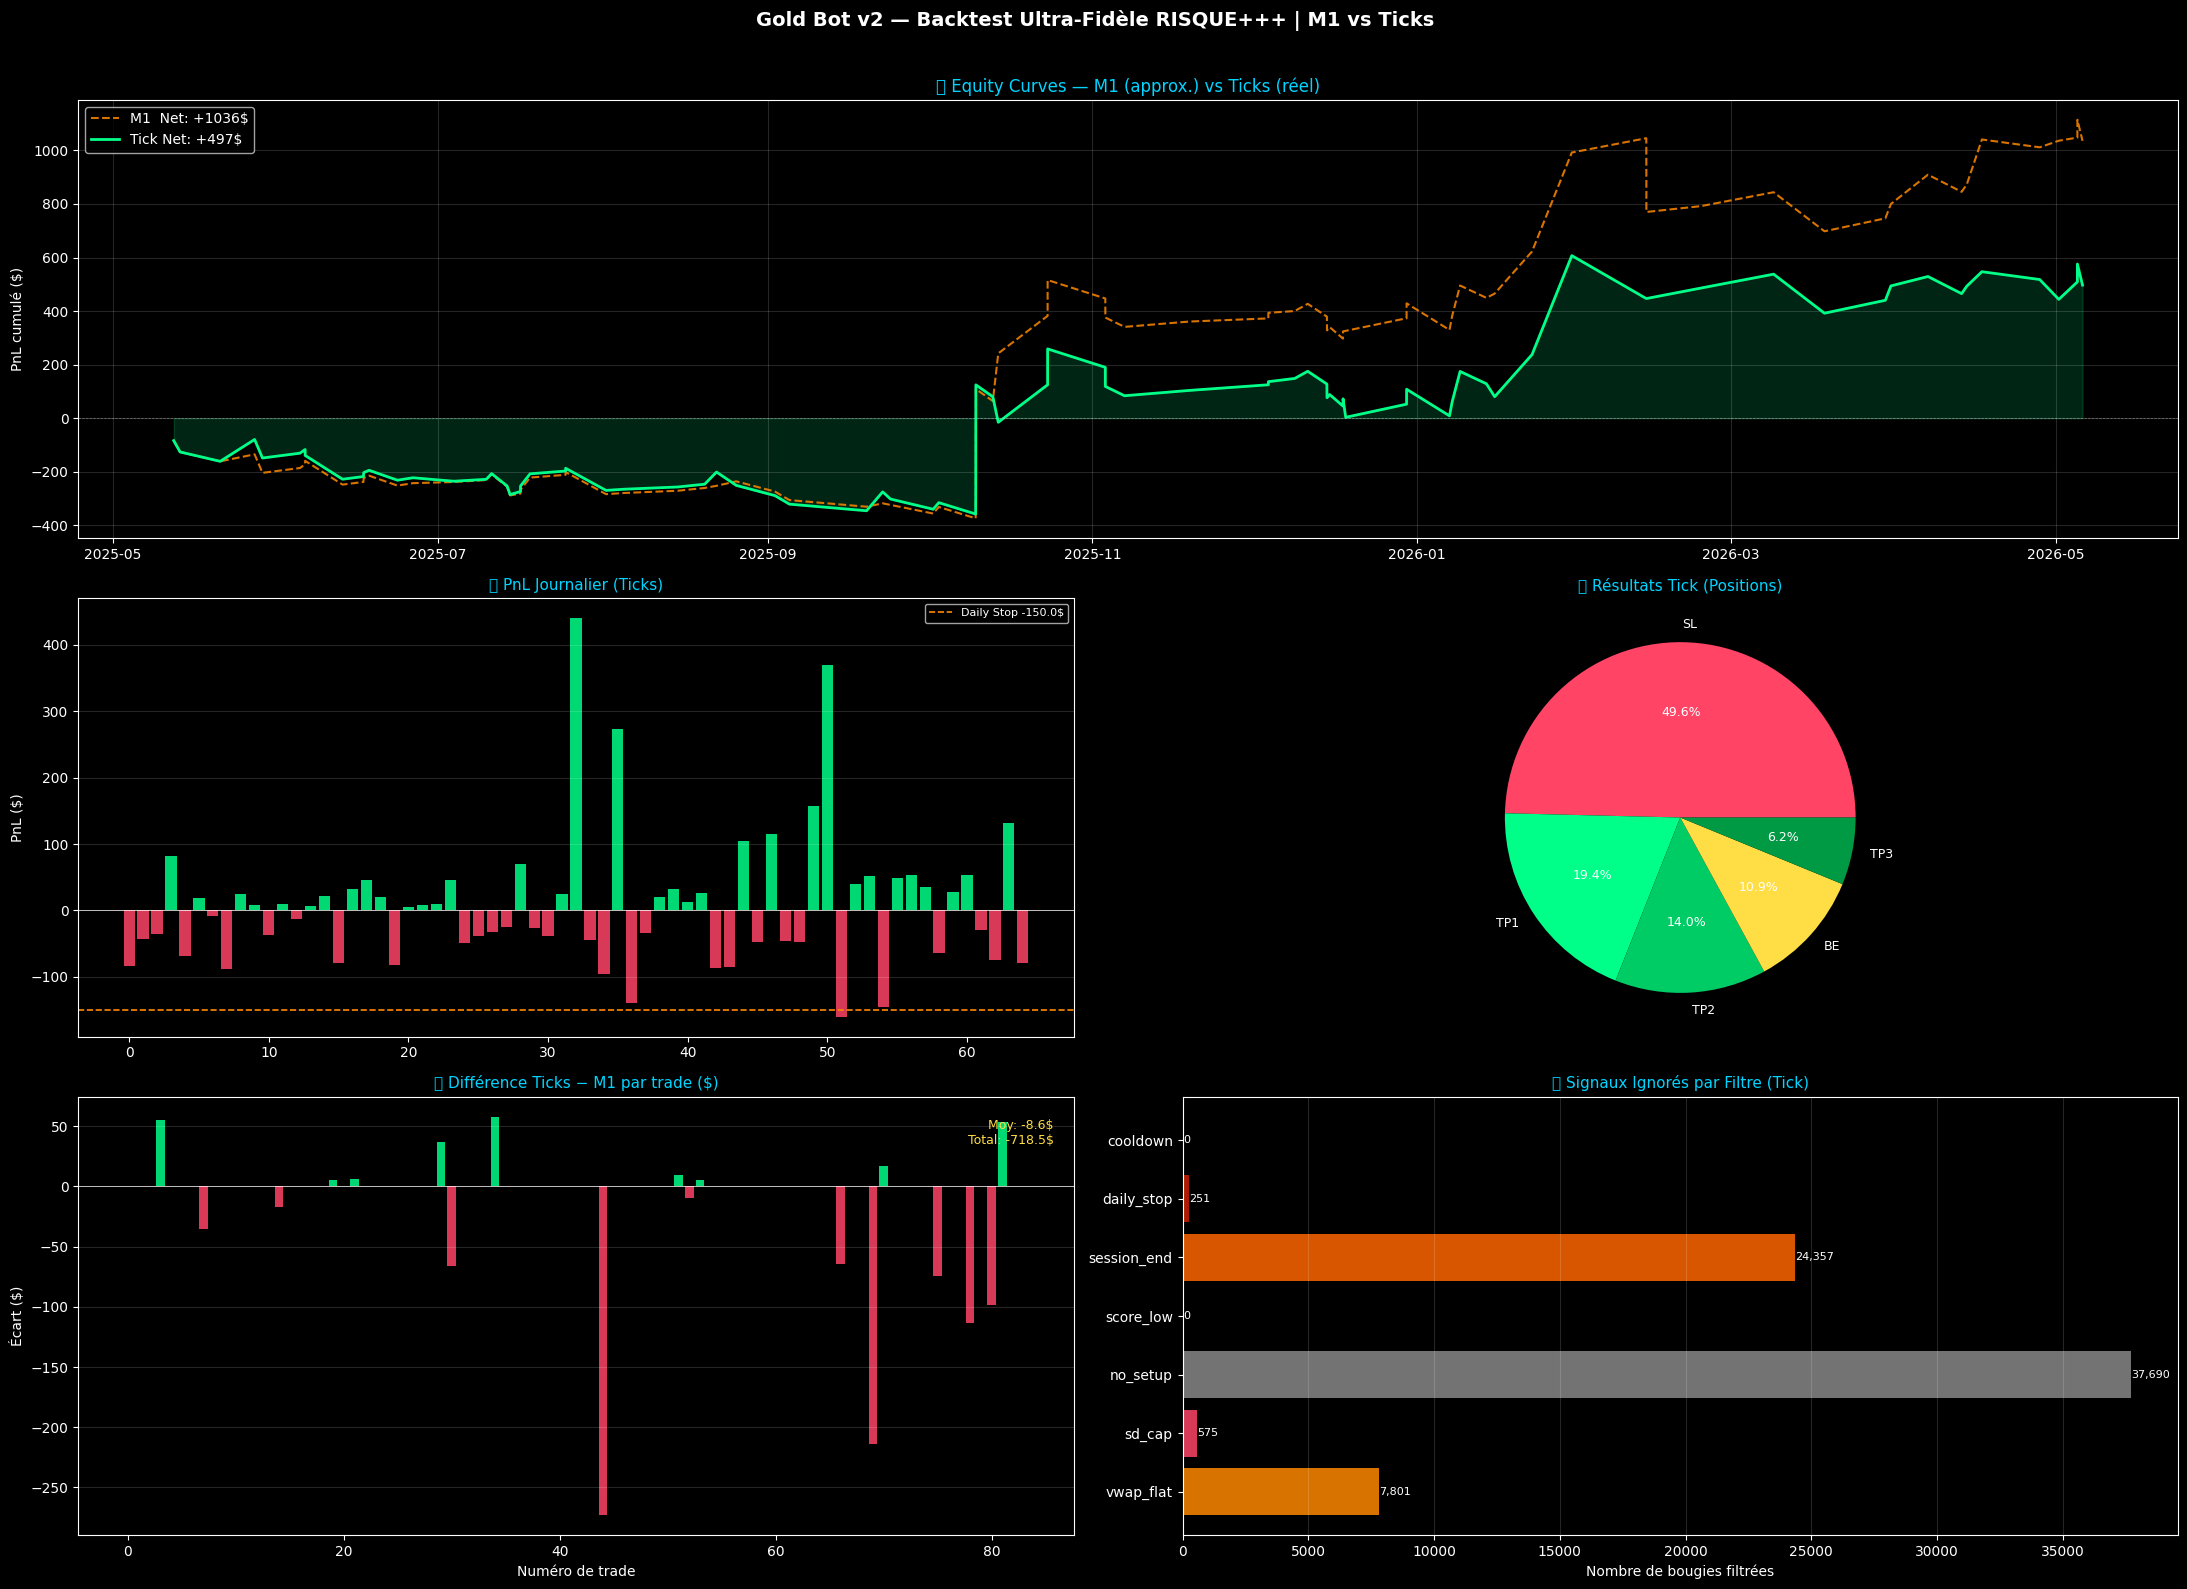

✅ Graphique sauvegardé → backtest_tick_results.png


In [216]:
# ============================================================
# CELLULE 10 — Graphiques (Equity Curves + Comparaison)
# ============================================================
if not df_trades_m1.empty and not df_trades_tick.empty:
    fig = plt.figure(figsize=(22, 16))
    fig.suptitle(
        f'Gold Bot v2 — Backtest Ultra-Fidèle {TRADING_MODE.upper()} | M1 vs Ticks',
        fontsize=14, fontweight='bold', color='white', y=0.99
    )

    # ── (1) Equity curves superposées ────────────────────────
    ax1 = fig.add_subplot(3, 2, (1, 2))
    eq_m1   = stats_m1['equity']
    eq_tick = stats_tick['equity']
    ax1.fill_between(eq_tick.index, eq_tick.values, alpha=0.15, color='#00ff88')
    ax1.plot(eq_m1.index,   eq_m1.values,   linewidth=1.5, color='#ff8800',
             label=f'M1  Net: {eq_m1.iloc[-1]:+.0f}$', linestyle='--', alpha=0.85)
    ax1.plot(eq_tick.index, eq_tick.values, linewidth=2.0, color='#00ff88',
             label=f'Tick Net: {eq_tick.iloc[-1]:+.0f}$')
    ax1.axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.4)
    ax1.set_title('📈 Equity Curves — M1 (approx.) vs Ticks (réel)', fontsize=12, color='#00d4ff')
    ax1.set_ylabel('PnL cumulé ($)', color='white')
    ax1.tick_params(colors='white'); ax1.grid(alpha=0.15)
    ax1.legend(fontsize=10)

    # ── (2) PnL journalier Ticks ──────────────────────────────
    ax2 = fig.add_subplot(3, 2, 3)
    daily = df_trades_tick.groupby('day')['pnl'].sum()
    bar_colors = ['#00ff88' if v >= 0 else '#ff4466' for v in daily.values]
    ax2.bar(range(len(daily)), daily.values, color=bar_colors, alpha=0.85)
    ax2.axhline(0, color='white', linewidth=0.5)
    ax2.axhline(DAILY_MAX_LOSS, color='#ff8800', linewidth=1.2, linestyle='--',
                label=f'Daily Stop {DAILY_MAX_LOSS}$')
    ax2.set_title('📅 PnL Journalier (Ticks)', fontsize=11, color='#00d4ff')
    ax2.set_ylabel('PnL ($)', color='white')
    ax2.tick_params(colors='white'); ax2.grid(alpha=0.15, axis='y')
    ax2.legend(fontsize=8)

    # ── (3) Répartition résultats Ticks ───────────────────────
    ax3 = fig.add_subplot(3, 2, 4)
    result_counts = df_trades_tick['result'].value_counts()
    palette = {'TP1': '#00ff88', 'TP2': '#00cc66', 'TP3': '#009944',
               'SL': '#ff4466', 'BE': '#ffdd44', 'OPEN_END': '#888888'}
    colors_pie = [palette.get(r, '#aaaaaa') for r in result_counts.index]
    ax3.pie(result_counts.values, labels=result_counts.index,
            autopct='%1.1f%%', colors=colors_pie,
            textprops={'color': 'white', 'fontsize': 9})
    ax3.set_title('🎯 Résultats Tick (Positions)', fontsize=11, color='#00d4ff')

    # ── (4) Différence M1 vs Tick par trade ───────────────────
    ax4 = fig.add_subplot(3, 2, 5)
    if not df_trades_m1.empty:
        seq_m1   = df_trades_m1.groupby('open_time')['pnl'].sum()
        seq_tick = df_trades_tick.groupby('open_time')['pnl'].sum()
        comp_df  = pd.concat([seq_m1, seq_tick], axis=1, keys=['m1', 'tick']).dropna()
        diff     = comp_df['tick'] - comp_df['m1']
        diff_colors = ['#00ff88' if v >= 0 else '#ff4466' for v in diff.values]
        ax4.bar(range(len(diff)), diff.values, color=diff_colors, alpha=0.85)
        ax4.axhline(0, color='white', linewidth=0.5)
        ax4.set_title('📊 Différence Ticks − M1 par trade ($)', fontsize=11, color='#00d4ff')
        ax4.set_xlabel('Numéro de trade', color='white')
        ax4.set_ylabel('Écart ($)', color='white')
        ax4.tick_params(colors='white'); ax4.grid(alpha=0.15, axis='y')
        ax4.text(0.98, 0.95, f'Moy: {diff.mean():+.1f}$\nTotal: {diff.sum():+.1f}$',
                 transform=ax4.transAxes, va='top', ha='right', color='#ffdd44', fontsize=9)

    # ── (5) Impact des filtres ────────────────────────────────
    ax5 = fig.add_subplot(3, 2, 6)
    labels_f = list(fs_tick.keys())
    values_f = list(fs_tick.values())
    colors_f = ['#ff8800', '#ff4466', '#888888', '#dd4400', '#ff6600', '#cc2200', '#996600']
    bars5 = ax5.barh(labels_f, values_f, color=colors_f[:len(labels_f)], alpha=0.85)
    ax5.set_title('🚦 Signaux Ignorés par Filtre (Tick)', fontsize=11, color='#00d4ff')
    ax5.set_xlabel('Nombre de bougies filtrées', color='white')
    ax5.tick_params(colors='white'); ax5.grid(alpha=0.15, axis='x')
    for bar, val in zip(bars5, values_f):
        ax5.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', color='white', fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig('backtest_tick_results.png', dpi=150, bbox_inches='tight',
                facecolor='#0d0d0d', edgecolor='none')
    plt.show()
    print('✅ Graphique sauvegardé → backtest_tick_results.png')



💻 CPU détecté : 6 cœurs disponibles
   → 6 workers en parallèle pour 40=40 combinaisons
🔬 Analyse de sensibilité PARALLÈLE en cours...

🚀 Lancement : 40 combos | 6 workers CPU


Sensibilité parallèle:   0%|                | 0/40 [00:00<?, ?combo/s]


✅ Sensibilité parallèle terminée en 82.1s (2.1s/combo)


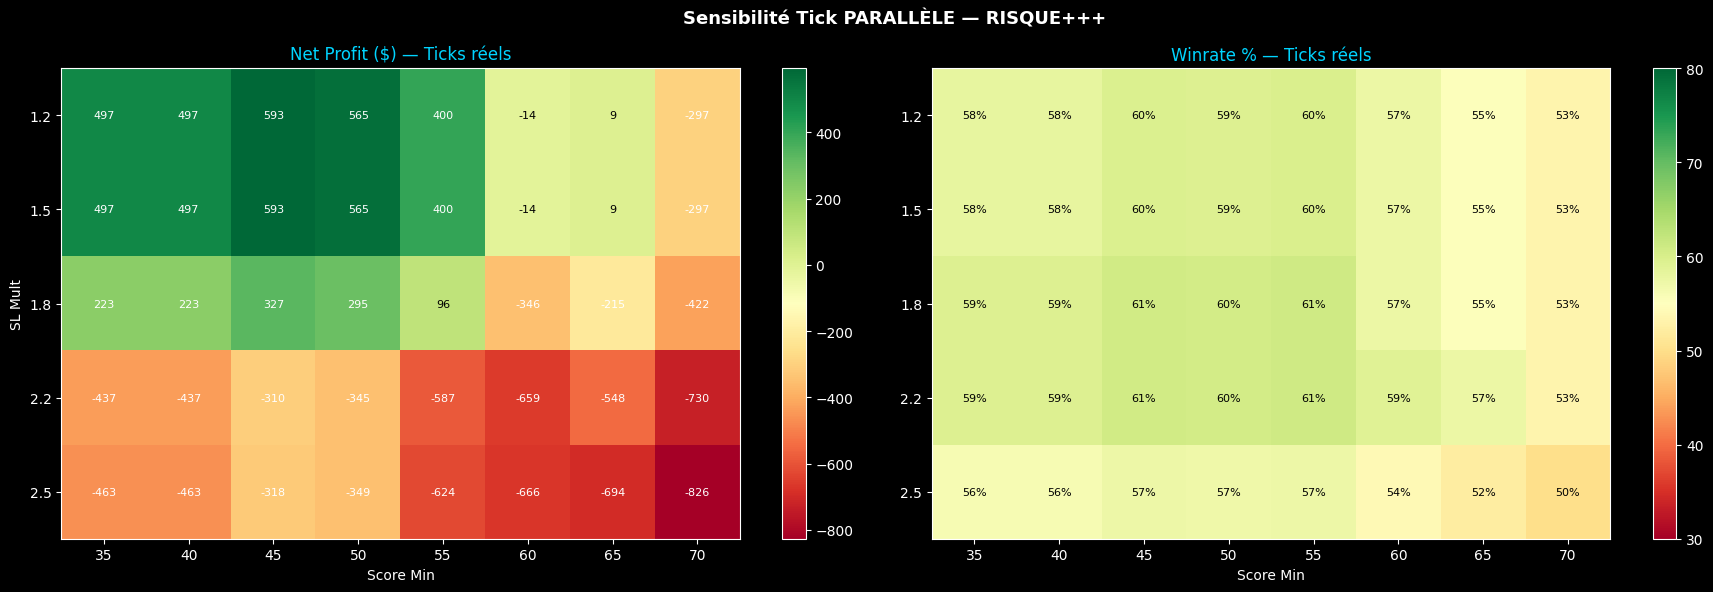


🏆 Meilleure combinaison : score_min=45.0 | sl_mult=1.5 → Net: +592.83$ | WR: 59.5%

💻 Utilisation CPU : 6 cœurs utilisés simultanément


In [217]:
# ============================================================
# CELLULE 11 (REMPLACEMENT) — Sensibilité PARALLÈLE
# ============================================================
# Utilise ProcessPoolExecutor pour lancer les 40 combinaisons
# en parallèle sur tous les cœurs CPU disponibles.
# Chaque worker reçoit les données via pickle (dict → rapide).

import multiprocessing
from concurrent.futures import ThreadPoolExecutor, as_completed
import copy

N_CORES = multiprocessing.cpu_count()
print(f'💻 CPU détecté : {N_CORES} cœurs disponibles')
print(f'   → {N_CORES} workers en parallèle pour {8*5}=40 combinaisons')


def _sensitivity_worker(args: tuple) -> dict:
    """
    Worker exécuté dans un processus séparé.
    Reçoit tout par valeur (pickle) — aucune variable globale partagée.
    """
    (precomp_items, tick_cache_local, mode, sm, slm,
     modes_config_local, pnl_per_pt) = args

    import copy, pandas as pd, numpy as np
    from collections import OrderedDict

    # Reconstituer le precomp OrderedDict depuis la liste (picklable)
    precomp = OrderedDict(precomp_items)

    m = modes_config_local[mode].copy()
    m['score_min'] = sm
    m['sl_mult']   = slm

    MAX_RISK      = 22.0
    SLIP          = 0.1
    SESSION_END   = 15
    SESSION_MID   = 12
    DAILY_MAX     = -150.0
    MAX_TRADES    = 60

    def _tp_sl(direction, entry, atr, sh, sl_lvl, mm):
        if direction == 'BUY':
            sl   = min(round(sl_lvl - atr*0.2, 2), round(entry - atr*mm['sl_mult'], 2))
            sl   = min(sl, round(entry - atr*max(mm['sl_mult'], 1.5), 2))
            risk = abs(entry - sl)
            if risk > MAX_RISK: sl = round(entry - MAX_RISK, 2); risk = MAX_RISK
            return {'sl':sl,'tp1':round(entry+risk*mm['tp1_mult'],2),
                    'tp2':round(entry+risk*mm['tp2_mult'],2),'tp3':round(entry+risk*mm['tp3_mult'],2)}
        else:
            sl   = max(round(sh + atr*0.2, 2), round(entry + atr*mm['sl_mult'], 2))
            sl   = max(sl, round(entry + atr*max(mm['sl_mult'], 1.5), 2))
            risk = abs(sl - entry)
            if risk > MAX_RISK: sl = round(entry + MAX_RISK, 2); risk = MAX_RISK
            return {'sl':sl,'tp1':round(entry-risk*mm['tp1_mult'],2),
                    'tp2':round(entry-risk*mm['tp2_mult'],2),'tp3':round(entry-risk*mm['tp3_mult'],2)}

    def _simulate(direction, entry_signal, levels, bids, asks):
        entry = round((asks[0]+SLIP) if direction=='BUY' else (bids[0]-SLIP), 2)
        delta = entry - entry_signal
        sl  = round(levels['sl'] +delta,2); tp1=round(levels['tp1']+delta,2)
        tp2 = round(levels['tp2']+delta,2); tp3=round(levels['tp3']+delta,2)
        pos = [{'id':'P1','tp':tp1,'sl':sl,'pnl':0.,'result':None,'closed':False},
               {'id':'P2','tp':tp2,'sl':sl,'pnl':0.,'result':None,'closed':False},
               {'id':'P3','tp':tp3,'sl':sl,'pnl':0.,'result':None,'closed':False}]
        tp1h=tp2h=False
        ep = bids if direction=='BUY' else asks
        for px in ep:
            if all(p['closed'] for p in pos): break
            for p in pos:
                if p['closed']: continue
                th=(px>=p['tp']) if direction=='BUY' else (px<=p['tp'])
                sh=(px<=p['sl']) if direction=='BUY' else (px>=p['sl'])
                if th and sh:
                    th=abs(p['tp']-entry)<abs(p['sl']-entry); sh=not th
                if th:
                    p['closed']=True; pts=(p['tp']-entry) if direction=='BUY' else (entry-p['tp'])
                    p['result']=p['id'].replace('P','TP'); p['pnl']=round(pts*pnl_per_pt,2)
                    if p['id']=='P1' and not tp1h:
                        tp1h=True
                        for o in pos:
                            if not o['closed']: o['sl']=entry
                    if p['id']=='P2' and not tp2h and tp1h:
                        tp2h=True
                        for o in pos:
                            if not o['closed']: o['sl']=tp1
                elif sh:
                    p['closed']=True; pts=abs(entry-p['sl'])
                    p['result']='BE' if abs(p['sl']-entry)<0.01 else 'SL'
                    p['pnl']=0. if p['result']=='BE' else round(-pts*pnl_per_pt,2)
        lp=ep[-1]
        for p in pos:
            if not p['closed']:
                pts=(lp-entry) if direction=='BUY' else (entry-lp)
                p['result']='OPEN_END'; p['pnl']=round(pts*pnl_per_pt,2); p['closed']=True
        return pos

    # ── Boucle principale du worker ───────────────────────────
    pnls       = []
    daily_pnl  = 0.; trades_today=0
    last_sl_ts = pd.Timestamp('1970-01-01')
    last_sig_ts= pd.Timestamp('1970-01-01')
    cur_date   = None; daily_stopped=False

    for ts, ind in precomp.items():
        day = ts.date()
        if day != cur_date:
            cur_date=day; daily_pnl=0.; trades_today=0; daily_stopped=False
        if daily_stopped: continue
        if daily_pnl < DAILY_MAX: daily_stopped=True; continue
        if trades_today >= MAX_TRADES: continue
        h = ts.hour
        if h >= SESSION_END: continue
        if (ts-last_sig_ts).total_seconds() < m['cooldown']: continue

        # Direction (inline simplifié — utilise le dict ind pré-calculé)
        vwap_slope = ind['vwap_slope']; atr = ind['atr']
        if abs(vwap_slope) < atr*0.1: continue
        dist = ind['dist_vwap_sd']
        if dist > 4.5 or dist < -4.5: continue

        price = ind['price']
        direction = None
        if ind['bounce_bull']:   direction='BUY'
        elif ind['bounce_bear']: direction='SELL'
        elif price<ind['vwap_lower1'] and (ind['near_swing_sup'] or ind['near_poc']) \
             and ind['above_200'] and ind['above_50'] and ind['vol_ratio']>1.0:
            direction='BUY'
        elif price>ind['vwap_upper1'] and (ind['near_swing_res'] or ind['near_poc']) \
             and not ind['above_200'] and not ind['above_50'] and ind['vol_ratio']>1.0:
            direction='SELL'
        elif price<ind['vwap_lower2'] and ind['above_200'] and ind['vol_ratio']>1.0:
            direction='BUY'
        elif price>ind['vwap_upper2'] and not ind['above_200'] and ind['vol_ratio']>1.0:
            direction='SELL'
        if direction is None: continue

        # Score inline
        score=0; is_buy=(direction=='BUY')
        dsd=abs(dist)
        if dsd>=2.0:score+=30
        elif dsd>=1.0:score+=18
        elif dsd>=0.5:score+=8
        if is_buy and vwap_slope>0:score+=5
        elif not is_buy and vwap_slope<0:score+=5
        if is_buy:
            if ind['near_swing_sup']:score+=15
            if ind['near_poc']:score+=10
            if price<ind['va_low']:score+=10
            if ind['above_200']:score+=5
        else:
            if ind['near_swing_res']:score+=15
            if ind['near_poc']:score+=10
            if price>ind['va_high']:score+=10
            if not ind['above_200']:score+=5
        vr=ind['vol_ratio']
        if ind['bounce_bull'] or ind['bounce_bear']:score+=25
        elif vr>=2.0:score+=20
        elif vr>=1.4:score+=12
        elif vr>=1.0:score+=5
        if is_buy and ind['ema_cross_bull']:score+=10
        elif not is_buy and ind['ema_cross_bear']:score+=10
        bull_p={'Marteau','Engulfing haussier','Pin Bar haussier'}
        bear_p={'Shooting Star','Engulfing baissier','Pin Bar baissier'}
        pat=ind['pattern']
        if is_buy and pat in bull_p:score+=15
        elif not is_buy and pat in bear_p:score+=15
        elif pat=='Doji':score+=3
        score=min(score,100)

        threshold=m['score_min']
        if h>=SESSION_MID:threshold+=10
        if (ts-last_sl_ts).total_seconds()<300:threshold+=20
        if score<threshold:continue
        if ts not in tick_cache_local:continue

        lvl=_tp_sl(direction,price,atr,ind['swing_high'],ind['swing_low'],m)
        bids,asks=tick_cache_local[ts]
        pos=_simulate(direction,price,lvl,bids,asks)
        if not pos:continue

        seq=sum(p['pnl'] for p in pos)
        daily_pnl=round(daily_pnl+seq,2); trades_today+=1; last_sig_ts=ts
        if any(p['result']=='SL' for p in pos): last_sl_ts=ts
        pnls.append(seq)

    # Métriques
    if not pnls:
        return {'score_min':sm,'sl_mult':slm,'net_profit':0,'n_seq':0,'winrate':0,'pf':0}
    arr    = np.array(pnls)
    net    = round(arr.sum(), 2)
    n_seq  = len(arr)
    wr     = round((arr>0).sum()/n_seq*100, 1)
    gw     = arr[arr>0].sum()
    gl     = abs(arr[arr<0].sum())
    pf     = round(gw/gl, 2) if gl>0 else 999
    return {'score_min':sm,'sl_mult':slm,'net_profit':net,'n_seq':n_seq,'winrate':wr,'pf':pf}


def run_sensitivity_parallel(precomp: OrderedDict,
                              tick_cache: dict,
                              mode: str,
                              score_range: list,
                              sl_range: list) -> pd.DataFrame:
    """
    Lance les 40 combinaisons en parallèle sur tous les cœurs CPU.
    Chaque worker est autonome (données copiées, pas de partage mémoire).
    """
    # Sérialiser precomp en liste (picklable entre processus)
    precomp_list = list(precomp.items())
    modes_copy   = copy.deepcopy(MODES_CONFIG_CACHE)

    combos = [(precomp_list, tick_cache, mode, sm, slm, modes_copy, PNL_PER_POINT)
              for sm in score_range for slm in sl_range]

    results = []
    n_workers = min(N_CORES, len(combos))
    print(f'🚀 Lancement : {len(combos)} combos | {n_workers} workers CPU')
    t0 = time.time()

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(_sensitivity_worker, args): args[3:5]
                   for args in combos}
        with tqdm_nb(total=len(combos), desc='Sensibilité parallèle',
                     unit='combo', ncols=70) as pbar:
            for future in as_completed(futures):
                try:
                    results.append(future.result())
                except Exception as e:
                    sm, slm = futures[future]
                    results.append({'score_min':sm,'sl_mult':slm,
                                    'net_profit':0,'n_seq':0,'winrate':0,'pf':0})
                    print(f'  ⚠️ Erreur combo sm={sm} slm={slm}: {e}')
                pbar.update(1)

    elapsed = time.time() - t0
    print(f'\n✅ Sensibilité parallèle terminée en {elapsed:.1f}s '
          f'({elapsed/len(combos):.1f}s/combo)')
    return pd.DataFrame(results)


# ── Lancement ─────────────────────────────────────────────────
# IMPORTANT : ProcessPoolExecutor nécessite le guard __name__=='__main__'
# Dans un Jupyter Notebook, ce guard n'est pas nécessaire car chaque
# cellule s'exécute dans le processus principal. Si tu l'exécutes en
# script .py, ajoute :  if __name__ == '__main__':

print('🔬 Analyse de sensibilité PARALLÈLE en cours...\n')
score_range = [35, 40, 45, 50, 55, 60, 65, 70]
sl_range    = [1.2, 1.5, 1.8, 2.2, 2.5]

df_sens = run_sensitivity_parallel(
    precomp_indicators, TICK_CACHE, TRADING_MODE,
    score_range, sl_range,
)

# ── Heatmaps ─────────────────────────────────────────────────
pivot    = df_sens.pivot(index='sl_mult', columns='score_min', values='net_profit')
pivot_wr = df_sens.pivot(index='sl_mult', columns='score_min', values='winrate')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Sensibilité Tick PARALLÈLE — {TRADING_MODE.upper()}',
             fontsize=13, fontweight='bold', color='white')

im1 = axes[0].imshow(pivot.values, aspect='auto', cmap='RdYlGn')
axes[0].set_xticks(range(len(pivot.columns)));   axes[0].set_xticklabels(pivot.columns, color='white')
axes[0].set_yticks(range(len(pivot.index)));     axes[0].set_yticklabels(pivot.index, color='white')
axes[0].set_xlabel('Score Min', color='white');  axes[0].set_ylabel('SL Mult', color='white')
axes[0].set_title('Net Profit ($) — Ticks réels', color='#00d4ff')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        axes[0].text(j, i, f"{pivot.values[i,j]:.0f}", ha='center', va='center', fontsize=8,
                     color='black' if abs(pivot.values[i,j]) < 200 else 'white')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pivot_wr.values, aspect='auto', cmap='RdYlGn', vmin=30, vmax=80)
axes[1].set_xticks(range(len(pivot_wr.columns))); axes[1].set_xticklabels(pivot_wr.columns, color='white')
axes[1].set_yticks(range(len(pivot_wr.index)));   axes[1].set_yticklabels(pivot_wr.index, color='white')
axes[1].set_xlabel('Score Min', color='white')
axes[1].set_title('Winrate % — Ticks réels', color='#00d4ff')
for i in range(len(pivot_wr.index)):
    for j in range(len(pivot_wr.columns)):
        axes[1].text(j, i, f"{pivot_wr.values[i,j]:.0f}%", ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.savefig('sensitivity_tick_parallel.png', dpi=130, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

best = df_sens.loc[df_sens['net_profit'].idxmax()]
print(f'\n🏆 Meilleure combinaison : score_min={best["score_min"]} | '
      f'sl_mult={best["sl_mult"]} → Net: {best["net_profit"]:+.2f}$ | WR: {best["winrate"]}%')
print(f'\n💻 Utilisation CPU : {N_CORES} cœurs utilisés simultanément')


In [218]:
# ============================================================
# CELLULE 12 — Notes & Paramètres de référence
# ============================================================
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 NOTES D'UTILISATION — BackTest v3 Tick
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Architecture :
  M5 → signaux (indicateurs, score, filtres)
  Ticks → exécution chirurgicale par trade

Friction réelle simulée :
  BUY  : entrée Ask + 0.5 pt (slippage)
  SELL : entrée Bid - 0.5 pt (slippage)
  BUY  : sortie TP/SL sur Bid (prix exécution réel MT5)
  SELL : sortie TP/SL sur Ask (prix exécution réel MT5)

Polars LazyFrame :
  141.7M ticks JAMAIS chargés en RAM d'un coup.
  Filtrage par plage de temps par trade uniquement.
  Streaming = mémoire constante (~50-200 MB/trade).

Paramètres fixes :
  MAX_RISK_PTS   = 22.0   (SL Cap absolu)
  DAILY_MAX_LOSS = -150$  (coupe-circuit)
  SESSION_END_H  = 15h    (arrêt nouveaux trades)
  GMT_OFFSET     = -1h    (Broker GMT+3 → PC GMT+2)
  SLIPPAGE_PTS   = 0.5    (latence broker)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 NOTES D'UTILISATION — BackTest v3 Tick
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Architecture :
  M5 → signaux (indicateurs, score, filtres)
  Ticks → exécution chirurgicale par trade

Friction réelle simulée :
  BUY  : entrée Ask + 0.5 pt (slippage)
  SELL : entrée Bid - 0.5 pt (slippage)
  BUY  : sortie TP/SL sur Bid (prix exécution réel MT5)
  SELL : sortie TP/SL sur Ask (prix exécution réel MT5)

Polars LazyFrame :
  141.7M ticks JAMAIS chargés en RAM d'un coup.
  Filtrage par plage de temps par trade uniquement.
  Streaming = mémoire constante (~50-200 MB/trade).

Paramètres fixes :
  MAX_RISK_PTS   = 22.0   (SL Cap absolu)
  DAILY_MAX_LOSS = -150$  (coupe-circuit)
  SESSION_END_H  = 15h    (arrêt nouveaux trades)
  GMT_OFFSET     = -1h    (Broker GMT+3 → PC GMT+2)
  SLIPPAGE_PTS   = 0.5    (latence broker)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

